In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../')
import mlflow
import torch
import numpy as np
import os
from src.utils import helpers
from src.utils import visualization as vis
from src.utils.model_registry import MLFlowRegistry
from src.core.params import BaseParams
from src.core.exported_model import ExportedModel
from src.data.datamodule import CrowdDataModule
from src.utils import inspection
from src.models import ensembled_model
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [ ]:
inspection.inspect_model('convnext_base')

In [2]:
model, params = MLFlowRegistry().load_model('models:/crowd_counting/68')

2026/07/27 23:57:23 WARNING mlflow.utils.requirements_utils: Detected one or more mismatches between the model's dependencies and the current Python environment:
 - matplotlib (current: 3.11.0, required: matplotlib==3.10.9)
To fix the mismatches, call `mlflow.pyfunc.get_model_dependencies(model_uri)` to fetch the model's environment and install dependencies using the resulting environment file.
/home/jl_fs/workspace/projects/crowd_counting/venv/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


RuntimeError: The NVIDIA driver on your system is too old (found version 12080). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver.

In [ ]:
type(model)

In [5]:
params

BaseParams(image_size=None, crop_size=384, label_scaler=1000, aug_factor=None, num_ops=None, backbone='tu-convnext_base', model_class='MAnet', backbone_weights='imagenet', decoder_attention_type=None, trainable_backbone=False, neck_out_channels=None, decoder_out_channels=128, dropout=None, batch_size=16, val_batch_size=1, lr=0.00065, l2_reg=0.0001, lr_schedule='clipped_exp', ssim_weight=0.3, mask_loss_weight=1, huber_delta=5, mask_loss_alpha=0.815, mask_loss_gamma=3.17, k_threshold=None, seg_threshold=None, gt_mask_threshold=0, monitor_metric='val_nae', loss_function='mask_mse_ssim', grad_accumulation=1, grad_clip=None, scheduler_kwargs={'decay_rate': 0.96, 'min_lr_pct': 0.01}, suggested_params=False, epochs=70, check_val_every_n_epoch=1, padding_multiple=32, dataset='part_A', train_size=268, unfrozen_blocks=None, optimizer_config={}, extra={})

In [4]:
# import numpy as np
# dummy_input = np.random.randint(0, 256, size=(2, 704, 1056, 3), dtype=np.uint8)
model.predict(torch.randn(2, 3, 704, 1056))

(tensor([5865.7954, 6205.7988], device='cuda:0'),
 tensor([[[1.9257e-03, 2.3117e-03, 2.2693e-03,  ..., 3.1649e-03,
           2.1422e-03, 1.3680e-03],
          [2.2711e-03, 2.5654e-03, 2.4185e-03,  ..., 4.3783e-03,
           3.9922e-03, 2.8397e-03],
          [3.0978e-03, 3.2859e-03, 3.5090e-03,  ..., 5.7323e-03,
           5.1882e-03, 3.9703e-03],
          ...,
          [3.7120e-04, 2.0158e-04, 1.1773e-04,  ..., 1.6800e-03,
           2.0631e-03, 1.8610e-03],
          [3.1698e-04, 1.8756e-04, 9.2930e-05,  ..., 9.7703e-04,
           1.3133e-03, 1.2585e-03],
          [3.9453e-04, 2.9018e-04, 1.7557e-04,  ..., 8.8452e-04,
           9.5165e-04, 8.4304e-04]],
 
         [[2.0858e-03, 3.3049e-03, 3.9734e-03,  ..., 2.3847e-03,
           1.6339e-03, 1.1861e-03],
          [2.1890e-03, 3.3519e-03, 3.8381e-03,  ..., 3.4419e-03,
           2.8592e-03, 1.8765e-03],
          [2.9044e-03, 4.0710e-03, 3.8558e-03,  ..., 3.9641e-03,
           3.6728e-03, 2.5370e-03],
          ...,
        

In [3]:
datamodule = CrowdDataModule(params=params)
datamodule.setup(stage=None)

2261 images found in /home/jl_fs/workspace/projects/crowd_counting/datasets/jhu-crowd-pp-v2/train/images
2261 gt files found in /home/jl_fs/workspace/projects/crowd_counting/datasets/jhu-crowd-pp-v2/train/ground-truth-npy
/home/jl_fs/workspace/projects/crowd_counting/datasets/jhu-crowd-pp-v2/valid found. Loading validation set from folder.
497 images found in /home/jl_fs/workspace/projects/crowd_counting/datasets/jhu-crowd-pp-v2/valid/images
497 gt files found in /home/jl_fs/workspace/projects/crowd_counting/datasets/jhu-crowd-pp-v2/valid/ground-truth-npy
1600 images found in /home/jl_fs/workspace/projects/crowd_counting/datasets/jhu-crowd-pp-v2/test/images
1600 gt files found in /home/jl_fs/workspace/projects/crowd_counting/datasets/jhu-crowd-pp-v2/test/ground-truth-npy


In [5]:
model.evaluate(datamodule)

OutOfMemoryError: CUDA out of memory. Tried to allocate 8.65 GiB. GPU 0 has a total capacity of 39.49 GiB of which 3.00 GiB is free. Including non-PyTorch memory, this process has 36.48 GiB memory in use. Of the allocated memory 35.87 GiB is allocated by PyTorch, and 67.44 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [6]:
datamodule.val_dataloader().batch_size

1

In [ ]:
"""{'mae': 105.06348419189453,
 'mbe': -6.24075174331665,
 'nae': 0.8911219239234924,
 'rmse': 340.9920959472656,
 'mask_dice': 0.491184800863266,
 'mask_iou': 0.3255434036254883}"""

In [4]:
from src.models.ensembled_model import EnsembledCrowdCounter
versions = ['52', '55', '56', '57']
sub_models = [mlflow.pyfunc.load_model(f'models:/crowd_counting/{version}') for version in versions]
model = EnsembledCrowdCounter(sub_models)
# model = mlflow.pyfunc.load_model('models:/crowd_counting/53')

/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


/home/zeus/miniconda3/envs/cloudspace/lib/python3.13/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


In [5]:
model.evaluate(datamodule.ensemble_test_dataloader())

{'MAE': 70.36506652832031,
 'NAE': 0.18059852719306946,
 'RMSE': 115.29673767089844}

In [27]:
sample, target, count = helpers.get_sample_from_dm(datamodule, index=11)
sample.shape

torch.Size([1, 3, 608, 928])

In [27]:
from torchvision.transforms import v2
from PIL import Image


from src.data import transform_sample
original_image = Image.open('/home/jl_fs/workspace/projects/crowd_counting/review_zeros/3139_jpg.rf.ade9d6799722481a373fd8b84a47797b.jpg').convert('RGB')
image = transform_sample.preprocess(original_image, params)
# image = np.array([original_image])

In [28]:
result  = model.predict(sample)
result = (float(result[0][0]), result[1])
result

(383.8077392578125,
 tensor([[[0.0010, 0.0015, 0.0018,  ..., 0.0003, 0.0004, 0.0004],
          [0.0012, 0.0017, 0.0022,  ..., 0.0003, 0.0003, 0.0004],
          [0.0014, 0.0021, 0.0026,  ..., 0.0003, 0.0004, 0.0004],
          ...,
          [0.0003, 0.0003, 0.0003,  ..., 0.0005, 0.0006, 0.0007],
          [0.0003, 0.0003, 0.0003,  ..., 0.0005, 0.0006, 0.0006],
          [0.0003, 0.0003, 0.0003,  ..., 0.0004, 0.0005, 0.0005]]],
        device='cuda:0'))

In [8]:
result = (result[0]['count'], result[0]['density_map'])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


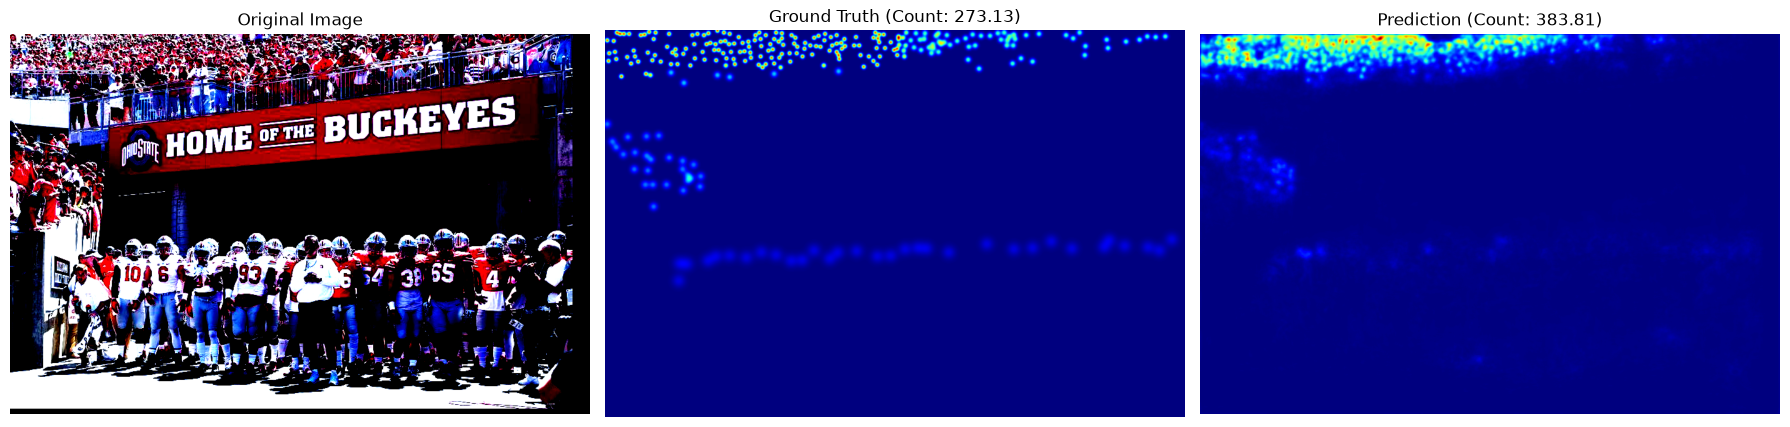

In [29]:
vis.visualize_sample(sample, target=(count, target), pred=result, cmap='jet')

In [11]:
vis.visualize_model_graph(model.model, sample=sample)

************
Feature extraction failed; returning model and environment to normal
*************
'Tensor' object has no attribute 'tl_tensor_label_raw'
